## Imports & Config

In [1]:
# !pip uninstall numba -y
# !pip install --upgrade numba

In [2]:
# !pip install xgboost

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DATA_DIR    = "dataset_voice"
EMOTIONS    = ["angry", "happy", "sad"]
SAMPLE_RATE = 22050
DURATION    = 3.0
N_MFCC      = 13
TEST_SIZE   = 0.2
RANDOM_SEED = 42

## Feature Extraction

In [3]:
def extract_features(file_path):
    audio, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION, mono=True)
    target_len = int(SAMPLE_RATE * DURATION)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    mfccs       = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    mfcc_mean   = np.mean(mfccs, axis=1)
    f0          = librosa.yin(audio, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"))
    pitch_mean  = float(np.mean(f0))
    energy_mean = float(np.mean(librosa.feature.rms(y=audio)))

    return np.append(mfcc_mean, [pitch_mean, energy_mean])

## Build Dataset

In [4]:
X, y = [], []

for emotion in EMOTIONS:
    folder = os.path.join(DATA_DIR, emotion)
    files  = [f for f in os.listdir(folder) if f.endswith((".wav", ".mp3", ".flac"))]
    print(f"{emotion}: {len(files)} files")
    for fname in files:
        try:
            X.append(extract_features(os.path.join(folder, fname)))
            y.append(emotion)
        except Exception as e:
            print(f"  [skip] {fname} — {e}")

X = np.array(X)
print(f"\nTotal: {len(y)} samples | Feature vector size: {X.shape[1]}")

angry: 2167 files
happy: 2167 files
sad: 2167 files

Total: 6501 samples | Feature vector size: 15


## Train / Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")

Train: 5200  |  Test: 1301


## Train SVM

In [6]:
svm = SVC(kernel="rbf", C=5, gamma="scale", random_state=RANDOM_SEED, probability=True)
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)
acc_svm    = accuracy_score(y_test, y_pred_svm)

print(f"Test Accuracy: {acc_svm*100:.1f}%\n")
print(classification_report(y_test, y_pred_svm, target_names=EMOTIONS, zero_division=0))

Test Accuracy: 82.9%

              precision    recall  f1-score   support

       angry       0.85      0.80      0.82       433
       happy       0.78      0.77      0.77       434
         sad       0.86      0.92      0.89       434

    accuracy                           0.83      1301
   macro avg       0.83      0.83      0.83      1301
weighted avg       0.83      0.83      0.83      1301



## Train XGBoost

In [7]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED
)
xgb.fit(X_train_sc, y_train_enc)

y_pred_xgb = le.inverse_transform(xgb.predict(X_test_sc))
acc_xgb    = accuracy_score(y_test, y_pred_xgb)

print(f"Test Accuracy: {acc_xgb*100:.1f}%\n")
print(classification_report(y_test, y_pred_xgb, target_names=EMOTIONS, zero_division=0))

Test Accuracy: 82.5%

              precision    recall  f1-score   support

       angry       0.83      0.79      0.81       433
       happy       0.77      0.77      0.77       434
         sad       0.88      0.92      0.90       434

    accuracy                           0.82      1301
   macro avg       0.82      0.82      0.82      1301
weighted avg       0.82      0.82      0.82      1301



## Cross-Validation

In [8]:
X_scaled = StandardScaler().fit_transform(X)
y_enc    = LabelEncoder().fit_transform(y)

cv_svm = cross_val_score(
    SVC(kernel="rbf", C=5, gamma="scale", random_state=RANDOM_SEED),
    X_scaled, y, cv=5, scoring="accuracy"
)
cv_xgb = cross_val_score(
    XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8,
                  use_label_encoder=False, eval_metric="mlogloss",
                  random_state=RANDOM_SEED),
    X_scaled, y_enc, cv=5, scoring="accuracy"
)

print(f"SVM     CV — Mean: {cv_svm.mean():.4f}  Std: {cv_svm.std():.4f}")
print(f"XGBoost CV — Mean: {cv_xgb.mean():.4f}  Std: {cv_xgb.std():.4f}")

SVM     CV — Mean: 0.6566  Std: 0.1309
XGBoost CV — Mean: 0.6244  Std: 0.1345


## Confusion Matrices

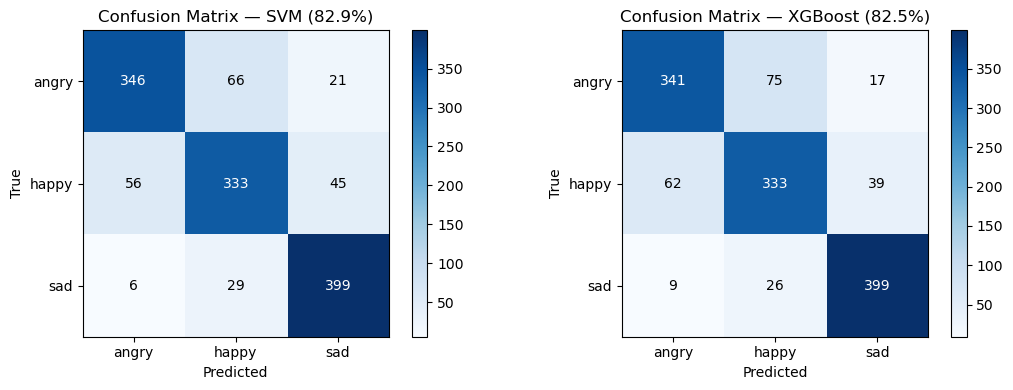

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_svm, y_pred_xgb],
    [f"SVM ({acc_svm*100:.1f}%)", f"XGBoost ({acc_xgb*100:.1f}%)"],
):
    cm = confusion_matrix(y_test, preds, labels=EMOTIONS)
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(EMOTIONS)))
    ax.set_yticks(range(len(EMOTIONS)))
    ax.set_xticklabels(EMOTIONS)
    ax.set_yticklabels(EMOTIONS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {title}")
    for i in range(len(EMOTIONS)):
        for j in range(len(EMOTIONS)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150)
plt.show()

## Summary

In [10]:
print("=" * 40)
print(f"{'Model':<12} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 40)
print(f"{'SVM':<12} {acc_svm*100:>9.1f}% {cv_svm.mean()*100:>9.1f}% {cv_svm.std()*100:>9.1f}%")
print(f"{'XGBoost':<12} {acc_xgb*100:>9.1f}% {cv_xgb.mean()*100:>9.1f}% {cv_xgb.std()*100:>9.1f}%")
print("=" * 40)

Model          Test Acc    CV Mean     CV Std
----------------------------------------
SVM               82.9%      65.7%      13.1%
XGBoost           82.5%      62.4%      13.4%


In [11]:
import time

# Accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# Inference latency — single sample, averaged over 1000 runs
sample = X_test_sc[0:1]

t0 = time.perf_counter()
for _ in range(1000):
    svm.predict(sample)
svm_ms = (time.perf_counter() - t0)

t0 = time.perf_counter()
for _ in range(1000):
    xgb.predict(sample)
xgb_ms = (time.perf_counter() - t0)

print(f"{'Model':<12} {'Accuracy':>10} {'Latency (ms)':>15}")
print("-" * 38)
print(f"{'SVM':<12} {acc_svm*100:>9.1f}% {svm_ms:>14.3f}")
print(f"{'XGBoost':<12} {acc_xgb*100:>9.1f}% {xgb_ms:>14.3f}")

Model          Accuracy    Latency (ms)
--------------------------------------
SVM               82.9%          0.520
XGBoost           82.5%          0.962
